In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import clustering_utils as utils

In [3]:
info_clustering = utils.load_clustering_data(
    "../datasets/info_clustering_ready.csv"
)

info_clustering.head()

Dataset loaded successfully: 31886 rows, 20 columns


,number_complaints,distinct_stores_visited,lifetime_total_distinct_products,percentage_of_products_bought_promotion,customer_age,tenure,total_children,total_spend,pct_spend_groceries,pct_spend_vegetables,pct_spend_nonalcohol_drinks,pct_spend_alcohol_drinks,pct_spend_meat,pct_spend_fish,pct_spend_hygiene,pct_spend_petfood,pct_spend_technology,is_male,customer_loyalty_flag,customer_id
0,0.0,0.0,0.464789,1.053227,0.032258,-0.833333,0.0,-0.117007,-0.323595,-0.040005,-0.102796,-0.430718,-0.955587,-0.426501,-0.041155,0.379723,1.470720,0,1,3.0
1,-1.0,-0.5,0.049296,-0.309665,-0.161290,0.333333,-1.0,-0.000883,-0.105288,1.618110,0.437975,-0.588808,-0.935888,-0.799274,1.670547,1.235155,-0.205745,0,1,4.0
2,-1.0,-0.5,-0.295775,-0.538171,-0.032258,1.666667,-2.0,-0.331937,0.472297,0.286472,-0.758809,-0.494018,1.585308,-0.214325,0.037716,-0.067146,-0.701519,1,0,5.0
3,1.0,-1.0,-0.218310,-0.016214,-0.387097,-1.000000,-2.0,-0.374132,-0.943085,-0.341782,1.902370,1.739668,1.065107,1.694490,0.033128,-0.205253,0.833068,1,1,7.0
4,2.0,-1.0,-0.823944,-0.205891,0.032258,-1.000000,-2.0,0.392367,-1.634630,-0.151431,0.233278,0.169133,0.313880,0.543584,-0.533364,0.130239,3.282303,1,1,8.0


In [4]:
customer_ids, X = utils.prepare_clustering_matrix(
    info_clustering,
    id_col="customer_id"
)

X.head()

Clustering matrix prepared: 31886 rows, 19 features


,number_complaints,distinct_stores_visited,lifetime_total_distinct_products,percentage_of_products_bought_promotion,customer_age,tenure,total_children,total_spend,pct_spend_groceries,pct_spend_vegetables,pct_spend_nonalcohol_drinks,pct_spend_alcohol_drinks,pct_spend_meat,pct_spend_fish,pct_spend_hygiene,pct_spend_petfood,pct_spend_technology,is_male,customer_loyalty_flag
0,0.0,0.0,0.464789,1.053227,0.032258,-0.833333,0.0,-0.117007,-0.323595,-0.040005,-0.102796,-0.430718,-0.955587,-0.426501,-0.041155,0.379723,1.470720,0,1
1,-1.0,-0.5,0.049296,-0.309665,-0.161290,0.333333,-1.0,-0.000883,-0.105288,1.618110,0.437975,-0.588808,-0.935888,-0.799274,1.670547,1.235155,-0.205745,0,1
2,-1.0,-0.5,-0.295775,-0.538171,-0.032258,1.666667,-2.0,-0.331937,0.472297,0.286472,-0.758809,-0.494018,1.585308,-0.214325,0.037716,-0.067146,-0.701519,1,0
3,1.0,-1.0,-0.218310,-0.016214,-0.387097,-1.000000,-2.0,-0.374132,-0.943085,-0.341782,1.902370,1.739668,1.065107,1.694490,0.033128,-0.205253,0.833068,1,1
4,2.0,-1.0,-0.823944,-0.205891,0.032258,-1.000000,-2.0,0.392367,-1.634630,-0.151431,0.233278,0.169133,0.313880,0.543584,-0.533364,0.130239,3.282303,1,1


In [5]:
kmeans_results = utils.evaluate_kmeans_range(
    X,
    min_k=2,
    max_k=10
)

kmeans_results

Computing metrics for k from 2 to 10
--------------------------------------------------
k=2: Inertia=456199, Silhouette=0.2625
k=3: Inertia=392507, Silhouette=0.2371
k=4: Inertia=341789, Silhouette=0.2308
k=5: Inertia=312431, Silhouette=0.2232
k=6: Inertia=291987, Silhouette=0.1630
k=7: Inertia=277576, Silhouette=0.1661
k=8: Inertia=263195, Silhouette=0.1694
k=9: Inertia=253353, Silhouette=0.1578
k=10: Inertia=245405, Silhouette=0.1613


,k,inertia,silhouette
0,2,456199.377264,0.262550
1,3,392507.451911,0.237071
2,4,341789.351764,0.230834
3,5,312431.469687,0.223152
4,6,291986.514027,0.163002
5,7,277576.416021,0.166136
6,8,263195.465289,0.169351
7,9,253352.701061,0.157762
8,10,245405.073941,0.161314


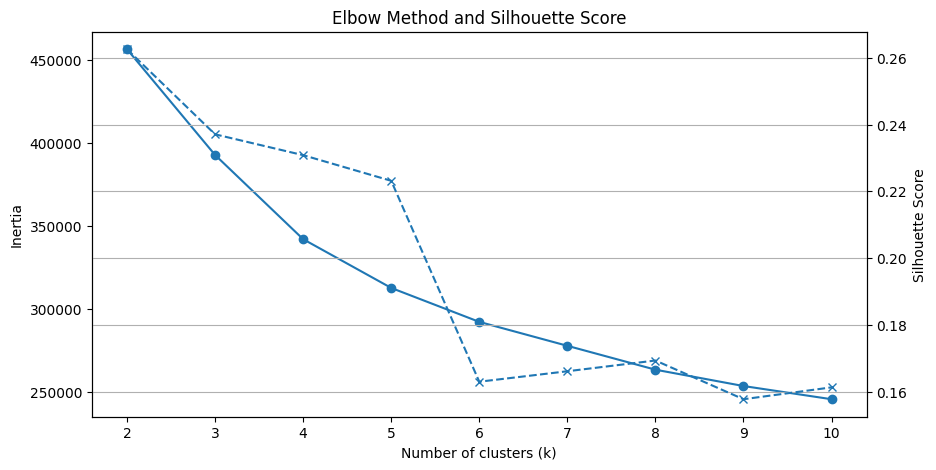

In [7]:
utils.plot_elbow_silhouette(kmeans_results)

In [15]:
final_k = 4

kmeans_model, info_clustering_kmeans, final_score = utils.run_final_kmeans(
    info_clustering,
    X,
    final_k=final_k
)

Final k: 4
Final Silhouette Score: 0.2308


In [16]:
cluster_summary = utils.cluster_size_summary(info_clustering_kmeans)

cluster_summary

,count,percentage
kmeans_cluster,,
0,3579,11.22
1,19344,60.67
2,2932,9.20
3,6031,18.91


In [17]:
centroids_df = utils.get_centroids(kmeans_model, X)

centroids_df

,number_complaints,distinct_stores_visited,lifetime_total_distinct_products,percentage_of_products_bought_promotion,customer_age,tenure,total_children,total_spend,pct_spend_groceries,pct_spend_vegetables,pct_spend_nonalcohol_drinks,pct_spend_alcohol_drinks,pct_spend_meat,pct_spend_fish,pct_spend_hygiene,pct_spend_petfood,pct_spend_technology,is_male,customer_loyalty_flag
kmeans_cluster,,,,,,,,,,,,,,,,,,,
0,0.048338,-0.652976,-0.038924,0.085722,0.044815,-0.303576,-1.368818,0.120651,-1.712708,-0.235791,0.481843,1.012706,0.433068,0.669452,-0.408271,-0.002220,3.113854,0.478905,0.485611
1,-0.044245,0.166512,0.141397,0.429808,-0.029399,0.035527,-0.339639,0.302403,0.238919,0.140997,-0.165405,0.012959,0.074804,0.048312,0.042181,0.053828,-0.110547,0.498475,0.615031
2,-0.031719,0.107776,1.190271,-0.095371,0.091993,0.363063,4.355730,1.218342,-0.255265,0.018850,0.231041,0.637284,0.329968,0.454859,-0.129536,-0.324451,0.543009,0.509550,0.675307
3,-0.290644,0.254562,-0.050756,-0.095296,0.094874,-0.047252,-0.191274,-0.504306,-0.946897,1.985950,1.299036,0.189878,0.053318,0.002263,1.883857,1.170982,0.308700,0.503484,0.603849


In [18]:
cluster_profile = (
    info_clustering_kmeans
    .drop(columns=["customer_id", "cluster_name"], errors="ignore")
    .groupby("kmeans_cluster")
    .mean()
)

cluster_profile

,number_complaints,distinct_stores_visited,lifetime_total_distinct_products,percentage_of_products_bought_promotion,customer_age,tenure,total_children,total_spend,pct_spend_groceries,pct_spend_vegetables,pct_spend_nonalcohol_drinks,pct_spend_alcohol_drinks,pct_spend_meat,pct_spend_fish,pct_spend_hygiene,pct_spend_petfood,pct_spend_technology,is_male,customer_loyalty_flag,customer_id
kmeans_cluster,,,,,,,,,,,,,,,,,,,,
0,0.048338,-0.652976,-0.038924,0.085722,0.044815,-0.303576,-1.368818,0.120651,-1.712708,-0.235791,0.481843,1.012706,0.433068,0.669452,-0.408271,-0.002220,3.113854,0.478905,0.485611,19956.485331
1,-0.044200,0.166615,0.141477,0.430028,-0.029434,0.035584,-0.339744,0.302382,0.238928,0.140818,-0.165530,0.013019,0.075140,0.048537,0.042003,0.053841,-0.110579,0.498501,0.615023,20035.672250
2,-0.031719,0.107776,1.190271,-0.095371,0.091993,0.363063,4.355730,1.218342,-0.255265,0.018850,0.231041,0.637284,0.329968,0.454859,-0.129536,-0.324451,0.543009,0.509550,0.675307,19678.441678
3,-0.290665,0.254187,-0.050917,-0.095743,0.094924,-0.047394,-0.191013,-0.503835,-0.946336,1.985607,1.298709,0.189598,0.052250,0.001562,1.883513,1.170384,0.308594,0.503399,0.603880,19979.271265


In [19]:
for cluster in centroids_df.index:

    print("\n")
    print("=" * 50)
    print(f"Cluster {cluster}")
    print("=" * 50)

    display(
        centroids_df.loc[cluster]
        .sort_values(ascending=False)
        .head(10)
    )



Cluster 0


pct_spend_technology                       3.113854
pct_spend_alcohol_drinks                   1.012706
pct_spend_fish                             0.669452
customer_loyalty_flag                      0.485611
pct_spend_nonalcohol_drinks                0.481843
is_male                                    0.478905
pct_spend_meat                             0.433068
total_spend                                0.120651
percentage_of_products_bought_promotion    0.085722
number_complaints                          0.048338
Name: 0, dtype: float64



Cluster 1


customer_loyalty_flag                      0.615031
is_male                                    0.498475
percentage_of_products_bought_promotion    0.429808
total_spend                                0.302403
pct_spend_groceries                        0.238919
distinct_stores_visited                    0.166512
lifetime_total_distinct_products           0.141397
pct_spend_vegetables                       0.140997
pct_spend_meat                             0.074804
pct_spend_petfood                          0.053828
Name: 1, dtype: float64



Cluster 2


total_children                      4.355730
total_spend                         1.218342
lifetime_total_distinct_products    1.190271
customer_loyalty_flag               0.675307
pct_spend_alcohol_drinks            0.637284
pct_spend_technology                0.543009
is_male                             0.509550
pct_spend_fish                      0.454859
tenure                              0.363063
pct_spend_meat                      0.329968
Name: 2, dtype: float64



Cluster 3


pct_spend_vegetables           1.985950
pct_spend_hygiene              1.883857
pct_spend_nonalcohol_drinks    1.299036
pct_spend_petfood              1.170982
customer_loyalty_flag          0.603849
is_male                        0.503484
pct_spend_technology           0.308700
distinct_stores_visited        0.254562
pct_spend_alcohol_drinks       0.189878
customer_age                   0.094874
Name: 3, dtype: float64

In [20]:
cluster_names = {
    0: "Technology and Premium Beverage Customers",
    1: "Promotion-Oriented Regular Customers",
    2: "High-Value Family Customers",
    3: "Fresh, Hygiene and Petfood Customers"
}

info_clustering_kmeans["cluster_name"] = (
    info_clustering_kmeans["kmeans_cluster"].map(cluster_names)
)

In [21]:
utils.save_clustered_data(
    info_clustering_kmeans,
    "../datasets/info_clustering_kmeans.csv"
)

File saved: ../datasets/info_clustering_kmeans.csv


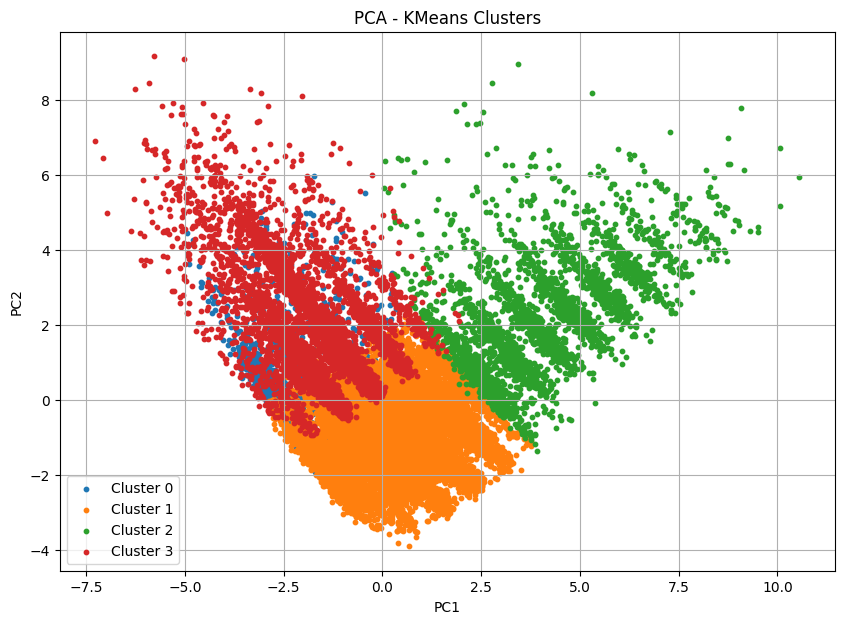

Explained variance by PC1 and PC2: 0.3958


In [22]:
utils.plot_pca_clusters(
    X,
    info_clustering_kmeans["kmeans_cluster"],
    title="PCA - KMeans Clusters"
)

/opt/anaconda3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


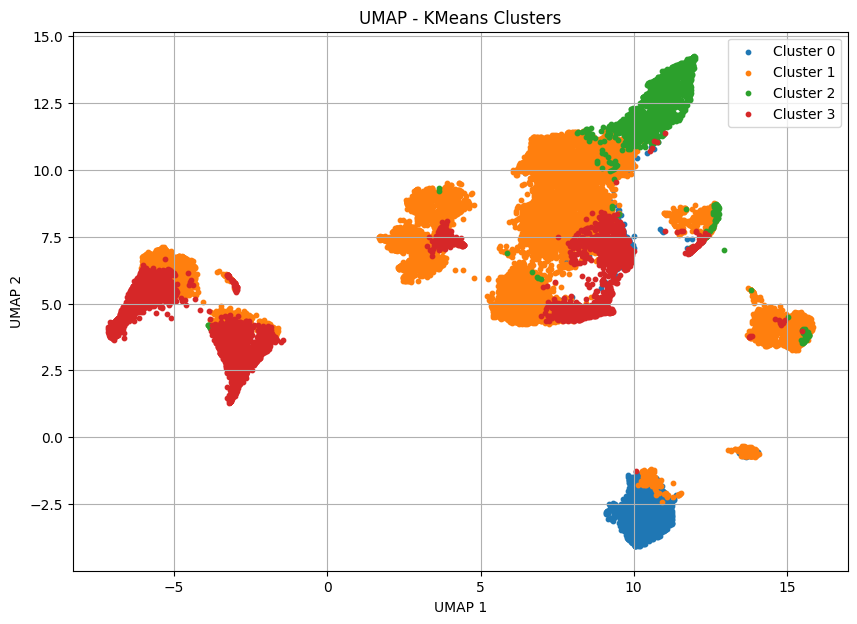

In [23]:
utils.plot_umap_clusters(
    X,
    info_clustering_kmeans["kmeans_cluster"],
    title="UMAP - KMeans Clusters"
)

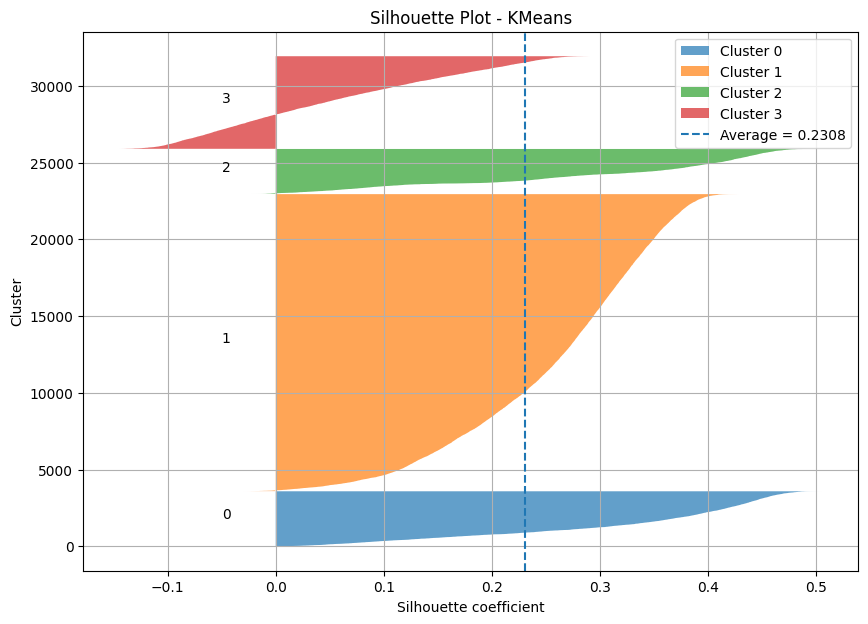

In [25]:
utils.silhouette_plot(
    X,
    info_clustering_kmeans["kmeans_cluster"],
    title="Silhouette Plot - KMeans"
)